In [1]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)
library(parallel)
library(ggplot2)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8



In [2]:
load("/vol/projects/yzhang/500FG_aging/output/02_Olink/olink_prediction_spearman_quoteID_gender.Rdata")

In [2]:
# olink <- readRDS("/vol/projects/CIIM/cohorts_old/500FG/olinkData/NPX_FG500.RDS")
# dim(olink)
# any(is.na(olink))
# olink <- as.data.frame(olink)
# head(olink)

[1] 424  70

[1] FALSE

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,CX3CL1,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,3.63611,9.48365,9.52098,2.30522,7.29957,2.53580,9.68034,6.69739,9.83187,2.65429,⋯,5.09046,6.45090,2.70225,9.03842,8.68959,3.22945,4.78947,4.93394,4.44519,9.53556
HV002,4.31364,9.69720,10.49119,1.97309,7.34675,3.16577,10.23258,7.63274,10.44883,2.01410,⋯,5.44641,6.73492,2.76555,9.75981,6.22762,4.50936,5.30881,5.22062,4.81664,9.72443
HV003,4.06539,10.19810,9.57446,2.28619,7.46174,2.91413,10.33496,7.45751,9.80417,3.37359,⋯,6.08994,6.77356,2.77692,8.77353,6.15381,4.79457,5.47104,5.15920,5.64723,10.37471
HV004,3.20146,9.97967,7.86780,2.22472,6.33368,2.29093,9.83527,6.53851,9.56768,3.32486,⋯,5.59638,6.68823,2.44064,8.87093,5.66952,4.72120,4.61117,5.74346,5.96514,10.25552
HV005,4.28828,10.10370,11.63828,2.26651,7.93486,3.32575,9.80797,7.58017,10.16342,2.64213,⋯,6.07405,7.26541,2.69546,9.52142,7.18970,4.65843,5.87574,5.37253,5.17238,9.85607
HV006,4.21672,10.11105,11.17692,2.53762,7.29801,2.96055,10.59224,6.94480,10.04118,2.97745,⋯,6.00473,7.15083,2.69737,9.67547,6.45433,3.70019,4.68181,5.17577,5.08267,9.98597


In [9]:
olink  <-  read.csv("/vol/projects/yzhang/500FG_aging/input/olink/olink_rank_normalized.csv",row.names=1)
head(olink)
dim(olink)
any(is.na(olink))

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,CX3CL1,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,-1.307515377,-1.8544190,-0.3719828,0.3530425,0.7784212,-0.61267034,-0.6269983,-1.2937415,-0.34048600,-0.08582721,⋯,-1.6850386,-1.1002426,-0.22960821,-0.5088619,2.16145282,-1.1221646,-0.76251161,-0.99775902,-0.85262386,-1.3959291
HV002,0.284609416,-0.9410132,0.8357388,-0.4167151,0.9318480,0.54280488,0.7546289,0.7625116,1.38043474,-1.71000931,⋯,-0.8026625,-0.3656548,-0.04435348,1.5152189,0.02069298,0.1573107,-0.06803884,0.09770089,-0.04435348,-0.4102756
HV003,-0.303127821,0.8526239,-0.3217508,0.3093235,1.2158118,0.09770089,0.9048100,0.4426501,-0.41027562,0.93184798,⋯,0.8273850,-0.2478567,-0.01478019,-1.0476252,-0.11553779,0.4038531,0.16329900,-0.16329900,1.49684359,2.0064213
HV004,-2.397454440,0.2053942,-1.7360943,0.1813000,-2.3039328,-1.04762520,-0.1692932,-1.7921234,-0.91374842,0.87841789,⋯,-0.3404860,-0.4821252,-0.94101316,-0.8784179,-0.79453027,0.3467574,-0.99775902,1.36526489,1.88847460,1.6380316
HV005,0.211435869,0.6055535,2.3039328,0.2600680,2.1614528,0.83573876,-0.2417650,0.6856648,0.47549533,-0.10958835,⋯,0.8026625,1.0476252,-0.25395762,0.8190886,1.15609694,0.2784586,0.72355395,0.52915474,0.85262386,0.1274492
HV006,0.002955934,0.6126703,1.8223874,0.7158943,0.7625116,0.20539420,1.3959291,-0.7467927,0.09770089,0.42317195,⋯,0.6342106,0.7158943,-0.24785670,1.2409543,0.34675740,-0.7158943,-0.93184798,-0.09176243,0.66339834,0.6782053


[1] 424  70

[1] FALSE

In [10]:
##fliter common sample in all layer
#common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/alllayer_common_samples.rds")   
#common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/multi-omics_common_sample_without_microbiome.rds") 
common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/alllayer_common_samples_nogenptype.rds")
olink <- olink[common_samples, , drop = FALSE]
dim(olink)
head(olink)
any(is.na(olink))

[1] 186  70

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,CX3CL1,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,1.1794789,0.1933331,-0.4622976,-1.0273721,0.57041505,0.94101316,-0.4491799,1.35040286,0.0266065,-0.67078345,⋯,0.1334115,-0.85262386,0.8026625,0.27845855,-0.4296465,0.5223666,1.3652649,0.008867905,-0.7082765,-0.9502581
HV028,-0.3217508,0.2417650,0.9880805,0.5914107,0.97849373,-0.03843655,-0.9318480,0.61267034,0.4557289,-0.85262386,⋯,0.7312563,1.20352406,1.0683174,0.63421059,0.4426501,-1.0683174,-0.7864502,0.175293452,0.6931626,0.1155378
HV029,-1.5943885,-0.7945303,-0.7625116,0.6487354,1.39592909,-0.84415123,-1.0075319,-0.58438359,-0.9227604,0.09770089,⋯,-2.5182949,-1.04762520,2.0527757,-1.26690663,1.8223874,-0.5359673,0.3593415,-2.397454440,-1.4789602,-1.6380316
HV030,-1.0374455,-0.2356822,0.7945303,1.1221646,-0.34048600,-1.22828601,-0.3974472,-0.62699826,-0.6707835,0.61267034,⋯,0.7864502,0.08582721,0.4491799,-1.15609694,-1.0374455,-1.0579147,-1.4615377,1.924872724,0.2114359,2.3039328
HV031,-1.1002426,-0.0266065,-1.1002426,-0.9977590,-0.81084824,0.48877641,0.6633983,0.07989501,-2.3039328,-0.78645022,⋯,-0.1155378,-0.18731317,-1.0075319,-1.41176602,-1.6610764,0.1393786,-1.0273721,-1.350402865,-0.1692932,0.7546289
HV033,0.3467574,0.1274492,-0.6269983,-1.0174019,-0.05027197,-0.26006800,-1.3215419,1.39592909,-0.2723182,0.63421059,⋯,-0.1873132,-0.91374842,1.5152189,-0.06803884,0.2235426,-0.4231719,0.4491799,0.802662538,0.1692932,-0.3342280


[1] FALSE

In [11]:
basicPhenos = read.csv("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_basicPhenos.csv")
basicPhenos <- basicPhenos[!is.na(basicPhenos$Age), ]
dim(basicPhenos)
# prepare cytokine_filter and pheno_filter_match
idx = intersect(rownames(olink), basicPhenos$ID_500fg) 
length(idx) #458samples
olink_filter = olink[which(rownames(olink) %in% idx),]
head(olink_filter)  #458samples,1596 metabolite
dim(olink_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(olink_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(olink_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(olink))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples
#saveRDS(olink_filter, file = "/vol/projects/yzhang/500FG_aging/output/02_Olink/common_olink_filter_agevariance(high).rds")
#saveRDS(basicPhenos_filter_match, file = "/vol/projects/yzhang/500FG_aging/output/02_Olink/common_basicPhenos_filter_match_olink_agevariance(high).rds")

[1] 527  16

[1] 186

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,CX3CL1,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,1.1794789,0.1933331,-0.4622976,-1.0273721,0.57041505,0.94101316,-0.4491799,1.35040286,0.0266065,-0.67078345,⋯,0.1334115,-0.85262386,0.8026625,0.27845855,-0.4296465,0.5223666,1.3652649,0.008867905,-0.7082765,-0.9502581
HV028,-0.3217508,0.2417650,0.9880805,0.5914107,0.97849373,-0.03843655,-0.9318480,0.61267034,0.4557289,-0.85262386,⋯,0.7312563,1.20352406,1.0683174,0.63421059,0.4426501,-1.0683174,-0.7864502,0.175293452,0.6931626,0.1155378
HV029,-1.5943885,-0.7945303,-0.7625116,0.6487354,1.39592909,-0.84415123,-1.0075319,-0.58438359,-0.9227604,0.09770089,⋯,-2.5182949,-1.04762520,2.0527757,-1.26690663,1.8223874,-0.5359673,0.3593415,-2.397454440,-1.4789602,-1.6380316
HV030,-1.0374455,-0.2356822,0.7945303,1.1221646,-0.34048600,-1.22828601,-0.3974472,-0.62699826,-0.6707835,0.61267034,⋯,0.7864502,0.08582721,0.4491799,-1.15609694,-1.0374455,-1.0579147,-1.4615377,1.924872724,0.2114359,2.3039328
HV031,-1.1002426,-0.0266065,-1.1002426,-0.9977590,-0.81084824,0.48877641,0.6633983,0.07989501,-2.3039328,-0.78645022,⋯,-0.1155378,-0.18731317,-1.0075319,-1.41176602,-1.6610764,0.1393786,-1.0273721,-1.350402865,-0.1692932,0.7546289
HV033,0.3467574,0.1274492,-0.6269983,-1.0174019,-0.05027197,-0.26006800,-1.3215419,1.39592909,-0.2723182,0.63421059,⋯,-0.1873132,-0.91374842,1.5152189,-0.06803884,0.2235426,-0.4231719,0.4491799,0.802662538,0.1692932,-0.3342280


[1] 186  70

,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
1,HV106,male,24,188,81,22.91761,Cohabitation,University degree,European,Never,No,Yes,16,12,346,2013
2,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014
3,HV521,male,23,171,68,23.25502,Cohabitation,University student,European,Once a month,No,No,8,12,338,2014
4,HV523,female,20,174,63,20.80856,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014
5,HV524,male,20,185,74,21.62162,Married,University student,European,Rarely,Yes,Yes,8,12,338,2014
6,HV527,female,50,164,66,24.53896,Married,Middelbaar beroepsonderwijs (MBO),European,Rarely,Yes,No,8,12,338,2014


[1] 186  16

[1] 0

[1] 186

,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
67,HV022,female,20,152,45,19.47715,Cohabitation,Middelbaar beroepsonderwijs (MBO),European,Rarely,No,No,3,10,273,2013
70,HV028,female,29,170,62,21.45329,Single living alone,Middelbaar beroepsonderwijs (MBO),European,Once a month,No,No,30,9,270,2013
59,HV029,male,24,188,97,27.44455,Married,Hogeschool opleiding (HBO),European,Daily,Yes,No,7,10,277,2013
68,HV030,female,25,161,57,21.98989,Single living alone,Hogeschool opleiding (HBO),European,Never,No,No,3,10,273,2013
60,HV031,female,21,180,66,20.37037,Married,University student,European,Once a month,Yes,No,7,10,277,2013
47,HV033,female,21,165,63,23.14050,Married,University student,European,Rarely,No,No,14,10,284,2013


[1] 186  16

In [3]:
olink_age <- cbind(olink_filter, Age = basicPhenos_filter_match$Age)
head(olink_age)
dim(olink_age)

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV022,1.1794789,0.1933331,-0.4622976,-1.0273721,0.57041505,0.94101316,-0.4491799,1.35040286,0.0266065,-0.67078345,⋯,-0.85262386,0.8026625,0.27845855,-0.4296465,0.5223666,1.3652649,0.008867905,-0.7082765,-0.9502581,20
HV028,-0.3217508,0.2417650,0.9880805,0.5914107,0.97849373,-0.03843655,-0.9318480,0.61267034,0.4557289,-0.85262386,⋯,1.20352406,1.0683174,0.63421059,0.4426501,-1.0683174,-0.7864502,0.175293452,0.6931626,0.1155378,29
HV029,-1.5943885,-0.7945303,-0.7625116,0.6487354,1.39592909,-0.84415123,-1.0075319,-0.58438359,-0.9227604,0.09770089,⋯,-1.04762520,2.0527757,-1.26690663,1.8223874,-0.5359673,0.3593415,-2.397454440,-1.4789602,-1.6380316,24
HV030,-1.0374455,-0.2356822,0.7945303,1.1221646,-0.34048600,-1.22828601,-0.3974472,-0.62699826,-0.6707835,0.61267034,⋯,0.08582721,0.4491799,-1.15609694,-1.0374455,-1.0579147,-1.4615377,1.924872724,0.2114359,2.3039328,25
HV031,-1.1002426,-0.0266065,-1.1002426,-0.9977590,-0.81084824,0.48877641,0.6633983,0.07989501,-2.3039328,-0.78645022,⋯,-0.18731317,-1.0075319,-1.41176602,-1.6610764,0.1393786,-1.0273721,-1.350402865,-0.1692932,0.7546289,21
HV033,0.3467574,0.1274492,-0.6269983,-1.0174019,-0.05027197,-0.26006800,-1.3215419,1.39592909,-0.2723182,0.63421059,⋯,-0.91374842,1.5152189,-0.06803884,0.2235426,-0.4231719,0.4491799,0.802662538,0.1692932,-0.3342280,21


[1] 186  71

In [4]:
# Create directory to store results
dir.create("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction_all_feature/olink_spearman_preparation", showWarnings = FALSE)

# Load the all_iterations_common_results1.rds file
all_iterations_common_results1 <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/Mvalue_spearman_preparation/all_iterations_common_results1.rds")

# Initialize list to store all iterations results
all_results <- list()

# Function to train and evaluate
train_and_evaluate <- function(data, seed, iteration) {
  #set.seed(seed)
   # Get the split indices from all_iterations_common_results1.rds
   iteration_result <- all_iterations_common_results1[[iteration]]
  split_indices <- iteration_result$split_indices[, 1]  # Extract the indices from the matrix
  # Split data
 # split_indices <- createDataPartition(data$Age, p = 0.7, list = FALSE)
    
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
  print(dim(training))  # Should have ~70% of the original rows
  # Should be 5000 (excluding Age) 
 
  # Get feature names
  feature_names <- setdiff(names(training), "Age")  
  feature_batches <- split(feature_names, ceiling(seq_along(feature_names) / 500))  
    print(length(feature_names))

  RNGkind("L'Ecuyer-CMRG")
  set.seed(123)
    
  # Compute Spearman correlation
  spearman_results <- mclapply(feature_batches, function(batch) {
    sapply(batch, function(feature) {
      if (!feature %in% names(training)) return(c(cor = NA, pvalue = NA))
      if (var(training[[feature]], na.rm = TRUE) == 0) return(c(cor = NA, pvalue = NA))
      
      test <- tryCatch(
        cor.test(training[[feature]], training$Age, method = "spearman"),
        error = function(e) return(NULL)
      )

      if (is.null(test)) return(c(cor = NA, pvalue = NA))
      return(c(cor = test$estimate, pvalue = test$p.value))
    }, simplify = FALSE)
  }, mc.cores = 8) 
      
       if (length(spearman_results) == 0 || is.null(spearman_results[[1]])) {
    stop("Error: spearman_results is empty or NULL. Check execution.")
  }
  print(length(spearman_results))
  # Extract p-values
  spearman_pvalues <- unlist(lapply(spearman_results, function(batch) {
    sapply(batch, function(x) if (!is.null(x)) x["pvalue"] else NA)
  }))
   print(summary(spearman_pvalues))  

  # Get corresponding feature names
  #feature_names <- names(spearman_pvalues)
 # names(spearman_pvalues) <- feature_names
   feature_names <- unlist(lapply(spearman_results, names))
  print(length(spearman_pvalues))  # p-value 总数
  print(head(spearman_pvalues))    # 预览前几个 p-values
  print(names(spearman_pvalues)[1:10])       
 
 
if (length(feature_names) != length(spearman_pvalues)) {
    stop("Error: Mismatch between feature names and spearman_pvalues length.")
  }
   names(spearman_pvalues) <- feature_names
  
    # Filter features with p-value < 0.05
   # selected_features <- names(spearman_pvalues[spearman_pvalues < 0.1])        
  selected_features <- names(spearman_pvalues) 
           
  # Store results in list
  results <- list(
    split_indices = split_indices,
    selected_features = selected_features,
    spearman_pvalues = spearman_pvalues[selected_features] # 只存筛选出的 p-value
  )

  rm(training, validation, feature_batches, spearman_results, spearman_pvalues, feature_names)
  gc()  

  return(results)
}

           
# Run 100 iterations
#for (i in 1:2) {
#  cat("Running iteration", i, "\n")
#  train_and_evaluate(Mvalue_age, seed = 123 + i, iteration = i)
#}
#iteration_results <- mclapply(1:100, function(i) {
iteration_results <- lapply(1:100, function(i) {
  train_and_evaluate(olink_age, seed = 123 + i, iteration = i)
})

# 合并结果
for (i in 1:100) {
  all_results[[i]] <- iteration_results[[i]]
}

           # Save all results in a single RDS file
if (length(all_results) > 0) {
  saveRDS(all_results, "/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction_all_feature/olink_spearman_preparation/olink_iterations_results_quoteID.rds")
} else {
  cat("Error: all_results is empty, nothing to save.\n")
}


[1] 132  71
[1] 70


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000003 0.1314986 0.3602120 0.3985061 0.6837855 0.9590528 
[1] 70
  1.IL8.pvalue 1.VEGFA.pvalue  1.CD8A.pvalue 1.CDCP1.pvalue 1.CD244.pvalue 
  8.252480e-01   9.590528e-01   1.176997e-01   3.153043e-07   1.671859e-01 
  1.IL7.pvalue 
  5.547041e-01 
 [1] "1.IL8.pvalue"            "1.VEGFA.pvalue"         
 [3] "1.CD8A.pvalue"           "1.CDCP1.pvalue"         
 [5] "1.CD244.pvalue"          "1.IL7.pvalue"           
 [7] "1.OPG.pvalue"            "1.LAP_TGF_beta_1.pvalue"
 [9] "1.uPA.pvalue"            "1.IL6.pvalue"           
[1] 132  71
[1] 70


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000003 0.1329675 0.3515546 0.3853784 0.6211437 0.9949509 
[1] 70
  1.IL8.pvalue 1.VEGFA.pvalue  1.CD8A.pvalue 1.CDCP1.pvalue 1.CD244.pvalue 
  6.236459e-01   7.262627e-01   1.329578e-01   3.065340e-07   5.787934e-01 
  1.IL7.pvalue 
  4.963417e-01 
 [1] "1.IL8.pvalue"            "1.VEGFA.pvalue"         
 [3] "1.CD8A.pvalue"           "1.CDCP1.pvalue"         
 [5] "1.CD244.pvalue"          "1.IL7.pvalue"           
 [7] "1.OPG.pvalue"            "1.LAP_TGF_beta_1.pvalue"
 [9] "1.uPA.pvalue"            "1.IL6.pvalue"           
[1] 132  71
[1] 70


...

[1] 1
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000038 0.1631815 0.3487300 0.4323525 0.6808008 0.9959715 
[1] 70
  1.IL8.pvalue 1.VEGFA.pvalue  1.CD8A.pvalue 1.CDCP1.pvalue 1.CD244.pvalue 
  9.069570e-01   4.599358e-01   2.307446e-01   3.796076e-06   1.696015e-01 
  1.IL7.pvalue 
  6.230245e-01 
 [1] "1.IL8.pvalue"            "1.VEGFA.pvalue"         
 [3] "1.CD8A.pvalue"           "1.CDCP1.pvalue"         
 [5] "1.CD244.pvalue"          "1.IL7.pvalue"           
 [7] "1.OPG.pvalue"            "1.LAP_TGF_beta_1.pvalue"
 [9] "1.uPA.pvalue"            "1.IL6.pvalue"           
[1] 132  71
[1] 70


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000002 0.0567762 0.2845458 0.3391341 0.5608005 0.9739216 
[1] 70
  1.IL8.pvalue 1.VEGFA.pvalue  1.CD8A.pvalue 1.CDCP1.pvalue 1.CD244.pvalue 
  2.549272e-01   7.930880e-01   1.178859e-01   1.653649e-07   5.197381e-02 
  1.IL7.pvalue 
  5.673781e-01 
 [1] "1.IL8.pvalue"            "1.VEGFA.pvalue"         
 [3] "1.CD8A.pvalue"           "1.CDCP1.pvalue"         
 [5] "1.CD244.pvalue"          "1.IL7.pvalue"           
 [7] "1.OPG.pvalue"            "1.LAP_TGF_beta_1.pvalue"
 [9] "1.uPA.pvalue"            "1.IL6.pvalue"           
[1] 132  71
[1] 70


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000004 0.083422 0.211752 0.333232 0.565368 0.995926 
[1] 70
  1.IL8.pvalue 1.VEGFA.pvalue  1.CD8A.pvalue 1.CDCP1.pvalue 1.CD244.pvalue 
  1.747530e-01   8.064999e-01   3.238946e-02   3.953784e-06   1.293747e-01 
  1.IL7.pvalue 
  3.915275e-01 
 [1] "1.IL8.pvalue"            "1.VEGFA.pvalue"         
 [3] "1.CD8A.pvalue"           "1.CDCP1.pvalue"         
 [5] "1.CD244.pvalue"          "1.IL7.pvalue"           
 [7] "1.OPG.pvalue"            "1.LAP_TGF_beta_1.pvalue"
 [9] "1.uPA.pvalue"            "1.IL6.pvalue"           


In [5]:
str(all_results)

List of 100
 $ :List of 3
  ..$ split_indices    : int [1:132] 1 3 4 5 6 7 8 9 10 12 ...
  ..$ selected_features: chr [1:70] "IL8" "VEGFA" "CD8A" "CDCP1" ...
  ..$ spearman_pvalues : Named num [1:70] 8.25e-01 9.59e-01 1.18e-01 3.15e-07 1.67e-01 ...
  .. ..- attr(*, "names")= chr [1:70] "IL8" "VEGFA" "CD8A" "CDCP1" ...
 $ :List of 3
  ..$ split_indices    : int [1:132] 2 4 6 7 8 10 11 12 13 14 ...
  ..$ selected_features: chr [1:70] "IL8" "VEGFA" "CD8A" "CDCP1" ...
  ..$ spearman_pvalues : Named num [1:70] 6.24e-01 7.26e-01 1.33e-01 3.07e-07 5.79e-01 ...
  .. ..- attr(*, "names")= chr [1:70] "IL8" "VEGFA" "CD8A" "CDCP1" ...
 $ :List of 3
  ..$ split_indices    : int [1:132] 1 2 3 4 7 8 10 11 12 13 ...
  ..$ selected_features: chr [1:70] "IL8" "VEGFA" "CD8A" "CDCP1" ...
  ..$ spearman_pvalues : Named num [1:70] 9.49e-01 4.99e-01 2.89e-01 5.39e-06 1.34e-01 ...
  .. ..- attr(*, "names")= chr [1:70] "IL8" "VEGFA" "CD8A" "CDCP1" ...
 $ :List of 3
  ..$ split_indices    : int [1:132] 1 2 3 5 

In [13]:
basicPhenos_filter_match$Gender <- trimws(as.character(basicPhenos_filter_match$Gender))
basicPhenos_filter_match$Gender[basicPhenos_filter_match$Gender == ""] <- NA

id2gender <- setNames(basicPhenos_filter_match$Gender, basicPhenos_filter_match$ID_500fg)
olink_age$Gender <- id2gender[rownames(olink_age)]

head(olink_age)
dim(olink_age)

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,IL6,⋯,NT_3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF_1,Age,Gender
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
HV022,1.1794789,0.1933331,-0.4622976,-1.0273721,0.57041505,0.94101316,-0.4491799,1.35040286,0.0266065,-0.67078345,⋯,0.8026625,0.27845855,-0.4296465,0.5223666,1.3652649,0.008867905,-0.7082765,-0.9502581,20,female
HV028,-0.3217508,0.2417650,0.9880805,0.5914107,0.97849373,-0.03843655,-0.9318480,0.61267034,0.4557289,-0.85262386,⋯,1.0683174,0.63421059,0.4426501,-1.0683174,-0.7864502,0.175293452,0.6931626,0.1155378,29,female
HV029,-1.5943885,-0.7945303,-0.7625116,0.6487354,1.39592909,-0.84415123,-1.0075319,-0.58438359,-0.9227604,0.09770089,⋯,2.0527757,-1.26690663,1.8223874,-0.5359673,0.3593415,-2.397454440,-1.4789602,-1.6380316,24,male
HV030,-1.0374455,-0.2356822,0.7945303,1.1221646,-0.34048600,-1.22828601,-0.3974472,-0.62699826,-0.6707835,0.61267034,⋯,0.4491799,-1.15609694,-1.0374455,-1.0579147,-1.4615377,1.924872724,0.2114359,2.3039328,25,female
HV031,-1.1002426,-0.0266065,-1.1002426,-0.9977590,-0.81084824,0.48877641,0.6633983,0.07989501,-2.3039328,-0.78645022,⋯,-1.0075319,-1.41176602,-1.6610764,0.1393786,-1.0273721,-1.350402865,-0.1692932,0.7546289,21,female
HV033,0.3467574,0.1274492,-0.6269983,-1.0174019,-0.05027197,-0.26006800,-1.3215419,1.39592909,-0.2723182,0.63421059,⋯,1.5152189,-0.06803884,0.2235426,-0.4231719,0.4491799,0.802662538,0.1692932,-0.3342280,21,female


[1] 186  72

In [6]:
###save each model iteration to use in the mutli-omics data
# Create a folder to save data for each experiment
dir.create("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/elasticnet/olink_spearman_pvalue_common_select_prediction_results_quoteID_elasticnet", showWarnings = FALSE)

# Load the all_iterations_common_results1.rds file
all_iterations_common_results1 <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/Mvalue_spearman_preparation/all_iterations_common_results1.rds")

# Custom function to train and evaluate, saving split indices and selected features
train_and_evaluate <- function(data, seed, iteration, pvalue_threshold) {

    # Gender cleanup (one missing value as blank string)
  # if (!"Gender" %in% names(data)) {
  #   stop("Gender column not found in input data.")
  # }
  # data$Gender <- trimws(as.character(data$Gender))
  # data$Gender[data$Gender == ""] <- NA
     # Get the split indices from all_iterations_common_results1.rds
   iteration_result <- all_iterations_common_results1[[iteration]]
  split_indices <- iteration_result$split_indices[, 1]  # Extract the indices from the matrix
  
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
  
 # Get the corresponding iteration results from both spearman results
  iteration_result <- all_results[[iteration]]

# Get p-values and features from the iteration result
all_pvalues <- iteration_result$spearman_pvalues
all_features <- iteration_result$selected_features
  
  # Ensure we're using the same split indices as in the spearman results
  if (!identical(split_indices, iteration_result$split_indices)) {
  warning("Split indices mismatch. Using original split indices from results.")
  split_indices <- iteration_result$split_indices
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
}

# Filter features based on p-value threshold
selected_features <- all_features[all_pvalues < pvalue_threshold]
   # Force Gender as a fixed feature
  # selected_features <- unique(c(selected_features, "Gender"))
    
  # Ensure we have selected features
  if (length(selected_features) == 0) {
    stop(paste("No features selected after filtering by p-value threshold", pvalue_threshold, "in iteration", iteration))
  }
  
  # Save split indices and selected features
  saveRDS(list(split_indices = split_indices, selected_features = selected_features),
          file = paste0("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/elasticnet/olink_spearman_pvalue_common_select_prediction_results_quoteID_elasticnet/iteration_", iteration, "_info.rds"))
  
  # Subset data to selected features
  training_selected <- training[, c(selected_features, "Age"), drop = FALSE]
  validation_selected <- validation[, c(selected_features, "Age"), drop = FALSE]
  
  # Drop rows with missing Gender after split, then encode Gender as numeric
  # training_selected <- training_selected[!is.na(training_selected$Gender), , drop = FALSE]
  # validation_selected <- validation_selected[!is.na(validation_selected$Gender), , drop = FALSE]
  # gender_levels <- sort(unique(na.omit(data$Gender)))
  # training_selected$Gender <- as.numeric(factor(training_selected$Gender, levels = gender_levels))
  # validation_selected$Gender <- as.numeric(factor(validation_selected$Gender, levels = gender_levels))
   
  rm(training)
  rm(validation)
  gc()

  # Model training using glmnet elasticnet
  netGrid <- expand.grid(.alpha = seq(0.1, 0.9, by = 0.1), .lambda = seq(0, 1, by = 0.01))  
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5)
  
  netFit <- train(Age ~ ., data = training_selected, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions
  train_predictions <- predict(netFit, newdata = training_selected)
  val_predictions <- predict(netFit, newdata = validation_selected)
  
    # save model
  saveRDS(netFit, 
          file = paste0("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/elasticnet/olink_spearman_pvalue_common_select_prediction_results_quoteID_elasticnet/iteration_", 
                       iteration, "_model.rds"))
  rm(netFit)
  gc()

    # Save predicted age for each sample
  pred_df <- rbind(
    data.frame(
      iteration = iteration,
      set = "train",
      sample_id = rownames(training_selected),
      Age_true = training_selected$Age,
      Age_pred = as.numeric(train_predictions)
    ),
    data.frame(
      iteration = iteration,
      set = "validation",
      sample_id = rownames(validation_selected),
      Age_true = validation_selected$Age,
      Age_pred = as.numeric(val_predictions)
    )
  )
    
      # Calculate performance metrics for the training set
train_rmse <- sqrt(mean((training_selected$Age - train_predictions)^2))  # RMSE
train_mse <- mean((training_selected$Age - train_predictions)^2)         # MSE
train_r_squared <- cor(training_selected$Age, train_predictions)^2       # R²

# Calculate performance metrics for the validation set
val_rmse <- sqrt(mean((validation_selected$Age - val_predictions)^2))    # RMSE
val_mse <- mean((validation_selected$Age - val_predictions)^2)           # MSE
val_r_squared <- cor(validation_selected$Age, val_predictions)^2         # R²
  
  rm(training_selected, validation_selected, train_predictions, val_predictions)
  gc()
      
      # Return results
return(list(
  train_RMSE = train_rmse,
  train_MSE = train_mse,               # Added MSE
  train_R2 = train_r_squared,
  val_RMSE = val_rmse,
  val_MSE = val_mse,                   # Added MSE
  val_R2 = val_r_squared,
  selected_features = selected_features,
  predictions = pred_df
))
}

In [7]:
set.seed(1)

batch_size <- 10  # 每个 batch 运行 10 次
num_batches <- 10  # 总 batch 数
results <- list() 

for (batch in 1:num_batches) {
    batch_results <- lapply(
    ((batch - 1) * batch_size + 1):(batch * batch_size), 
    function(i) {
       res <- train_and_evaluate(olink_age, seed = 123 + i, iteration = i, pvalue_threshold = 1)
      return(res)
    }
)
# Add batch results to results
  results <- c(results, batch_results)
  
  rm(batch_results)
  gc()
}

# Save all results in a single file
saveRDS(results, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet/olink_prediction_pvalue_common_select_results_spearman_quoteID_elasticnet.rds") 

# Save all predicted ages from 100 iterations in one file
all_predictions <- do.call(rbind, lapply(results, function(x) x$predictions))
write.csv(all_predictions, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet/olink_prediction_pvalue_common_select_age_predictions_quoteID_elasticnet.csv", row.names = FALSE)


In [8]:
# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)
                        
# Extract number of selected features for each iteration
num_selected_features <- sapply(results, function(x) length(x$selected_features))
                                
# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²",
             "Number of Selected Features"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values),
           mean(num_selected_features, na.rm = TRUE)), 
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values),
         sd(num_selected_features, na.rm = TRUE)) 
)
                              
# Print summary
print(metrics_summary)               

                       Metric       Mean          SD
1                  Train RMSE  7.3222654  0.70847671
2             Validation RMSE  9.1713441  1.25566116
3                   Train MSE 54.1124907  9.91094126
4              Validation MSE 85.6744708 24.13632932
5                    Train R²  0.6252285  0.06783455
6               Validation R²  0.4062147  0.10733561
7 Number of Selected Features 70.0000000  0.00000000


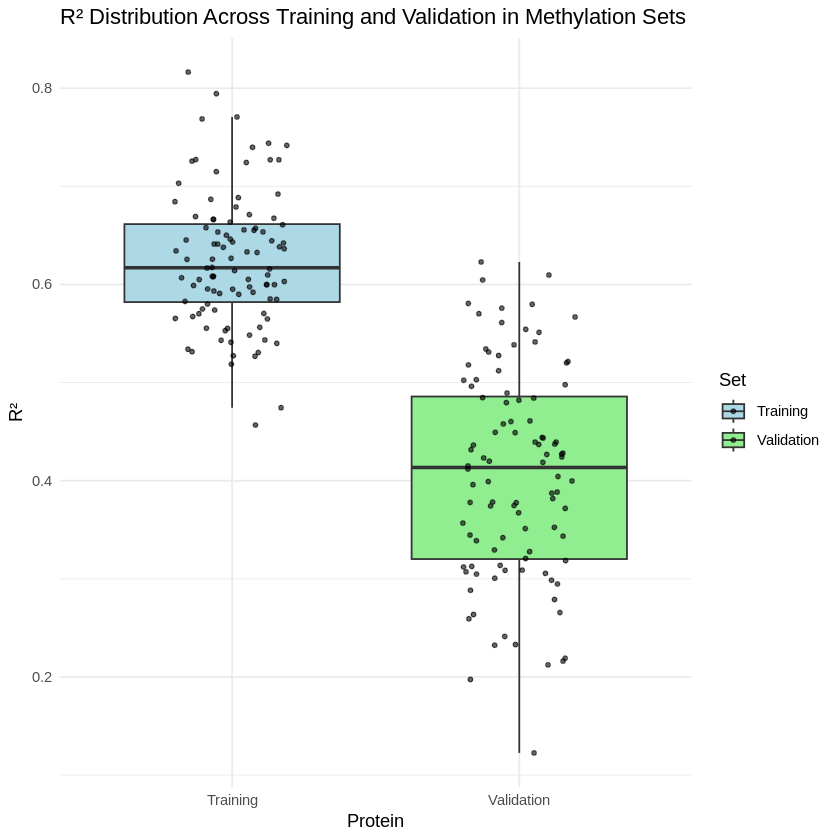

In [9]:
 plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)                                            
# Plot only R²
ppi <- 300
# png("/vol/projects/yzhang/500FG_aging/output/12_prediction/olink_predicition_pvalue_common_select_spearman.png", 
#     width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Methylation Sets",
       x = "Protein",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))
print(g)
# dev.off()    
# print(g)

In [10]:
save.image("/vol/projects/yzhang/500FG_aging/output/02_Olink/olink_prediction_spearman_quoteID_elasticnet.Rdata")